# Tutorial 3: Train NicheTrans on SMA data

In [17]:
import os, time, datetime, warnings

import torch
import torch.nn as nn
from torch.optim import lr_scheduler

from model.nicheTrans_img import *
from datasets.data_manager_SMA import SMA

from utils.utils import *
from utils.utils_training_SMA import train, test
from utils.utils_dataloader import *

warnings.filterwarnings("ignore")

### Initialize the args and fix seeds

In [18]:
%run ./args/args_SMA.py
args = args

set_seed(args.seed)
if torch.cuda.is_available():
    os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_devices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device: {}".format(device))
print("==========\nArgs:{}\n==========".format(args))

Using device: cpu
Args:Namespace(noise_rate=0.2, dropout_rate=0.1, use_moe_ffn=True, num_experts=4, moe_gate_hidden_dim=512, moe_gate_type='softmax', ffn_mult=2, moe_router_temperature_enable=True, moe_router_temperature_start=1.0, moe_router_temperature_mid=0.7, moe_router_temperature_end=0.5, moe_router_temperature_schedule='step', moe_balance_loss_enable=True, moe_balance_loss_weight=0.01, moe_balance_loss_type='mse_uniform', moe_router_entropy_penalty_enable=True, moe_router_entropy_penalty_weight=0.001, n_source=3000, n_target=50, img_size=256, workers=4, path_img='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used/patches', rna_path='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used', msi_path='/mnt/datadisk0/Processed_DATA/2023_nbt_SMA/Processed_data_used', max_epoch=40, stepsize=20, train_batch=32, test_batch=32, optimizer='adam', lr=0.0003, gamma=0.1, weight_decay=0.0005, seed=1, save_dir='./log', eval_step=1, gpu_devices='0')


### Initialize dataloaders and NicheTrans

In [19]:
# create the dataloaders
dataset = SMA(path_img=args.path_img, rna_path=args.rna_path, msi_path=args.msi_path, n_top_genes=args.n_source, n_top_targets=args.n_target)
trainloader, testloader = sma_dataloader(args, dataset)

# create the model
source_dimension, target_dimension = dataset.rna_length, dataset.msi_length
model = NicheTrans(source_length=source_dimension, target_length=target_dimension, noise_rate=args.noise_rate, dropout_rate=args.dropout_rate,num_experts=args.num_experts,moe_gate_hidden_dim=args.moe_gate_hidden_dim,moe_router_temperature_enable= args.moe_router_temperature_enable,moe_router_entropy_penalty_enable=args.moe_router_entropy_penalty_enable,moe_balance_loss_enable=args.moe_balance_loss_enable)
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

------Calculating spatial graph...
The graph contains 12134 edges, 3120 cells.
3.8891 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 24190 edges, 3120 cells.
7.7532 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 11322 edges, 2918 cells.
3.8801 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 22578 edges, 2918 cells.
7.7375 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 10360 edges, 2675 cells.
3.8729 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 20628 edges, 2675 cells.
7.7114 neighbors per cell on average.
=> SMA loaded
Dataset statistics:
  ------------------------------
  subset   | # num | 
  ------------------------------
  train    |  Without filtering  6038 spots from     2 slides 
  test     |  Without filtering  2675 spots from     1 slides
  train    |  After filting  6005 spots from     2 

### Initialize loss function (criterion) and optimizer

In [20]:
criterion = nn.MSELoss()

if args.optimizer == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
elif args.optimizer == 'SGD':
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
else:
    print('unexpected optimizer')

if args.stepsize > 0:
    scheduler = lr_scheduler.StepLR(optimizer, step_size=args.stepsize, gamma=args.gamma)

### Optional MoE Trajectory Tracking During Training

Enable the next cell if you want to monitor whether expert usage becomes more balanced or more specialized across epochs.


In [21]:
from utils.moe_analysis import analyze_moe_routing, summarize_epoch_trajectory

track_moe_during_training = True
moe_track_every = 1
moe_track_max_batches = None  # Set to a small integer for faster monitoring on large datasets.
moe_epoch_frames = {}
moe_epoch_overall = []



### Model training and testing

In [22]:
start_time = time.time()

if "track_moe_during_training" not in globals():
    track_moe_during_training = True
    moe_track_every = 1
    moe_track_max_batches = None
    moe_epoch_frames = {}
    moe_epoch_overall = []

for epoch in range(args.max_epoch):
    last_epoch = epoch + 1 == args.max_epoch

    print("==> Epoch {}/{}".format(epoch+1, args.max_epoch))
    
    ################
    train(model, criterion, optimizer, trainloader, use_img=False, device=device)
    if args.stepsize > 0: scheduler.step()

    if track_moe_during_training and ((epoch + 1) % moe_track_every == 0 or last_epoch):
        moe_epoch_result = analyze_moe_routing(
            model=model,
            dataloader=testloader,
            device=device,
            include_images=False,
            include_cell_information=False,
            include_predictions=False,
            include_targets=False,
            max_batches=moe_track_max_batches,
            add_spatial_regions=False,
        )
        moe_epoch_frames[epoch + 1] = moe_epoch_result["activation_frame"]
        moe_epoch_overall.append({"epoch": epoch + 1, **moe_epoch_result["overall"]})
        print("MoE tracking at epoch {}:".format(epoch + 1), moe_epoch_result["overall"])
    ################

pearson = test(model, testloader, use_img=False, device=device)
torch.save(model.state_dict(), 'NicheTrans_SMA_last.pth')

elapsed = round(time.time() - start_time)
elapsed = str(datetime.timedelta(seconds=elapsed))
print("Finished. Total elapsed time (h:m:s): {}".format(elapsed))


==> Epoch 1/40
Batch 187/187	 Loss 61.419659 (90.852281) | Task 90.851147 | Aux 0.001134 | Tau 1.0000 | Bal 0.011665 | Ent 1.121900 | Margin 0.091366 | Cos 0.583599
MoE tracking at epoch 1: {'num_center_spots': 2655, 'num_experts': 4, 'usage_entropy_normalised': 0.989006847103258, 'top1_entropy_normalised': 0.5238539343406505, 'effective_expert_count': 3.939503165565234, 'dominant_expert_fraction': 0.32070641398022964, 'mean_weight_l1_to_uniform': 0.14141282767951965, 'balance_loss': 0.013414283212898703, 'top1_l1_to_uniform': 0.9887005649717514, 'mean_spot_entropy': 0.8279666121889666, 'std_spot_entropy': 0.1460912318668287, 'mean_gate_margin': 0.11243376463034283, 'std_gate_margin': 0.0977894052527114, 'router_temperature': 1.0, 'router_entropy_penalty': 0.8280493214081012, 'expert_output_cosine_mean': 0.8250789031919562, 'expert_output_cosine_std': 0.1064749651288582}
==> Epoch 2/40
Batch 187/187	 Loss 31.786282 (42.701372) | Task 42.700780 | Aux 0.000592 | Tau 1.0000 | Bal 0.120138

### Optional MoE Routing Analysis

Run the next cell after training if you want to inspect expert activation, load balance, and spatial specialization.


Overall MoE metrics:
{'num_center_spots': 2655, 'num_experts': 4, 'usage_entropy_normalised': 0.5231768376346511, 'top1_entropy_normalised': 0.5243888331444903, 'effective_expert_count': 2.0653033159863545, 'dominant_expert_fraction': 0.6465667365434888, 'mean_weight_l1_to_uniform': 0.9614847782804123, 'balance_loss': 0.29439618906844583, 'top1_l1_to_uniform': 0.9600753295668549, 'mean_spot_entropy': 0.011796064423453188, 'std_spot_entropy': 0.0731648704372218, 'mean_gate_margin': 0.9913277733516591, 'std_gate_margin': 0.06470147031847877, 'router_temperature': 0.5, 'router_entropy_penalty': 0.011906126781065094, 'expert_output_cosine_mean': -0.08836009856839638, 'expert_output_cosine_std': 0.4814997874186313}


,expert,average_activation_weight,top1_selection_frequency
0,0,0.646567,0.645574
1,1,0.000170,0.000000
2,2,0.334176,0.334463
3,3,0.019088,0.019962


,slice_id,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,expert_2_top1_frequency,expert_3_top1_frequency,num_center_spots,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,V11L12-109_A1,0.646567,0.00017,0.334176,0.019088,0.645574,0.0,0.334463,0.019962,2655,...,0.294396,0.960075,0.011796,0.073165,0.991328,0.064701,0.5,0.011906,-0.08836,0.4815


,spatial_region,expert_0_mean_weight,expert_1_mean_weight,expert_2_mean_weight,expert_3_mean_weight,expert_0_top1_frequency,expert_1_top1_frequency,expert_2_top1_frequency,expert_3_top1_frequency,num_center_spots,...,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,V11L12-109_A1|x0_y0,0.746337,0.000105,0.222770,3.078828e-02,0.744318,0.0,0.222727,0.032955,880,...,0.295174,0.988636,0.017227,0.086157,0.986708,0.081840,0.5,0.012786,-0.085851,0.481208
1,V11L12-109_A1|x0_y1,0.979907,0.000003,0.020089,9.226509e-11,0.979911,0.0,0.020089,0.000000,448,...,0.297445,1.459821,0.000041,0.000081,0.999993,0.000014,0.5,0.011031,-0.090814,0.481528
2,V11L12-109_A1|x1_y0,0.225084,0.000083,0.767903,6.928823e-03,0.223214,0.0,0.767857,0.008929,448,...,0.287648,1.035714,0.004405,0.052473,0.996100,0.051799,0.5,0.011504,-0.089842,0.481572
3,V11L12-109_A1|x1_y1,0.591606,0.000364,0.384730,2.329966e-02,0.591581,0.0,0.385666,0.022753,879,...,0.295503,0.954494,0.016117,0.084780,0.989104,0.067049,0.5,0.011677,-0.088867,0.481741


,sample_id,slice_id,spot_id,x,y,batch_index,batch_spot_index,top1_expert,top1_weight,center_entropy,...,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,spatial_region
0,V11L12-109_A1/16_0,V11L12-109_A1,16_0,16.0,0.0,63,24,2,1.0,1.084517e-09,...,9.459185,9.851337,9.413156,0.0,0.000000,11.124052,10.766718,12.130200,10.306040,V11L12-109_A1|x0_y0
1,V11L12-109_A1/18_0,V11L12-109_A1,18_0,18.0,0.0,48,15,2,1.0,1.021832e-09,...,0.000000,8.492299,0.000000,0.0,0.000000,8.759887,0.000000,11.104244,10.788660,V11L12-109_A1|x0_y0
2,V11L12-109_A1/20_0,V11L12-109_A1,20_0,20.0,0.0,76,6,2,1.0,9.645063e-10,...,0.000000,10.286452,0.000000,0.0,8.627494,0.000000,0.000000,11.605639,11.130058,V11L12-109_A1|x0_y0
3,V11L12-109_A1/22_0,V11L12-109_A1,22_0,22.0,0.0,60,1,2,1.0,1.066662e-09,...,0.000000,11.559565,9.218695,0.0,0.000000,0.000000,0.000000,11.876929,11.200499,V11L12-109_A1|x0_y0
4,V11L12-109_A1/24_0,V11L12-109_A1,24_0,24.0,0.0,32,0,2,1.0,1.084673e-09,...,0.000000,11.640724,0.000000,0.0,0.000000,8.050138,8.727013,11.898485,7.776558,V11L12-109_A1|x0_y0


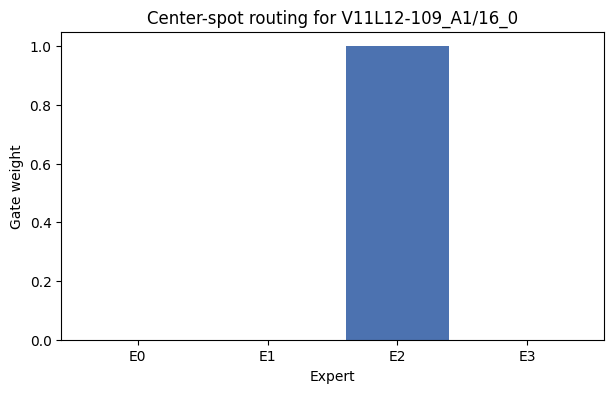

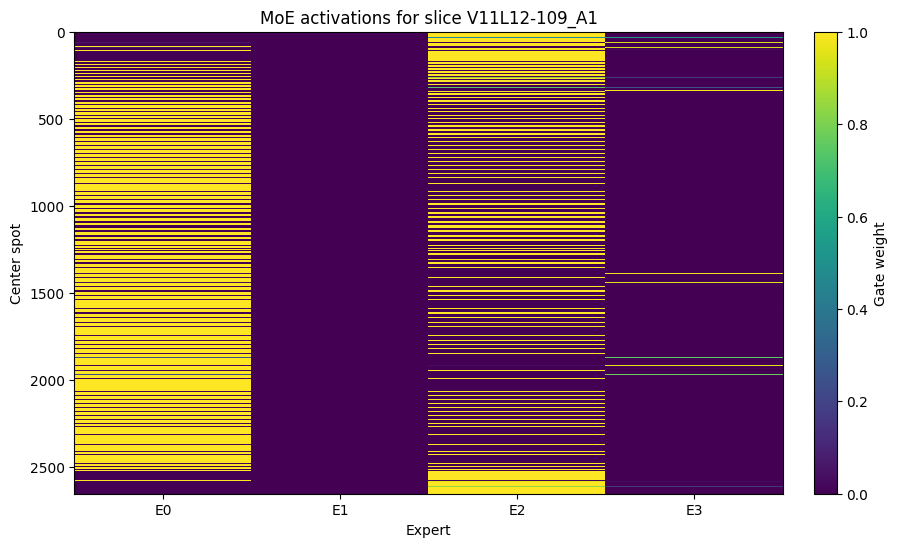

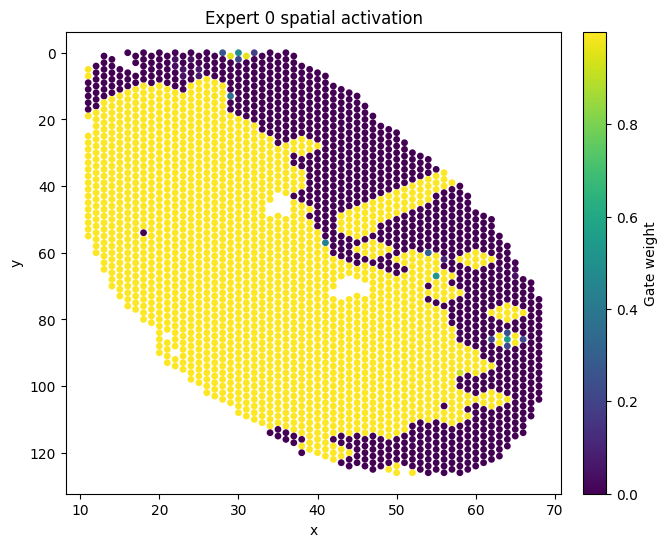

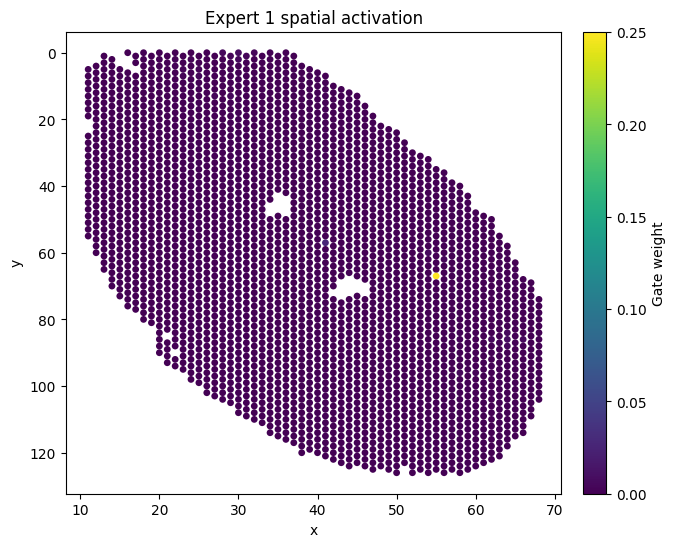

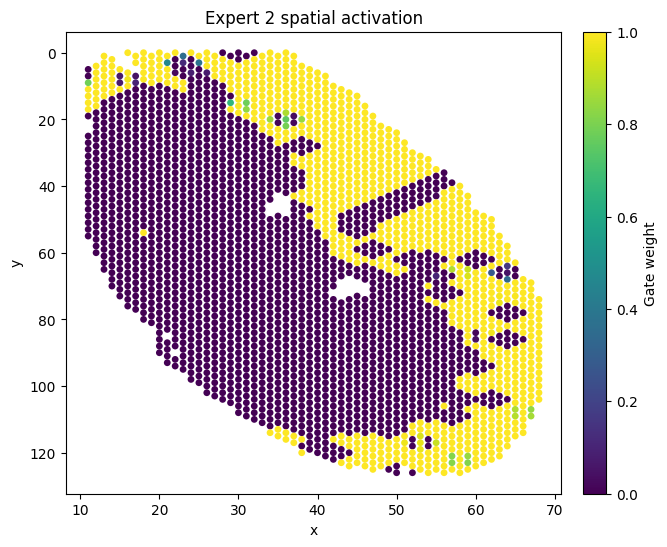

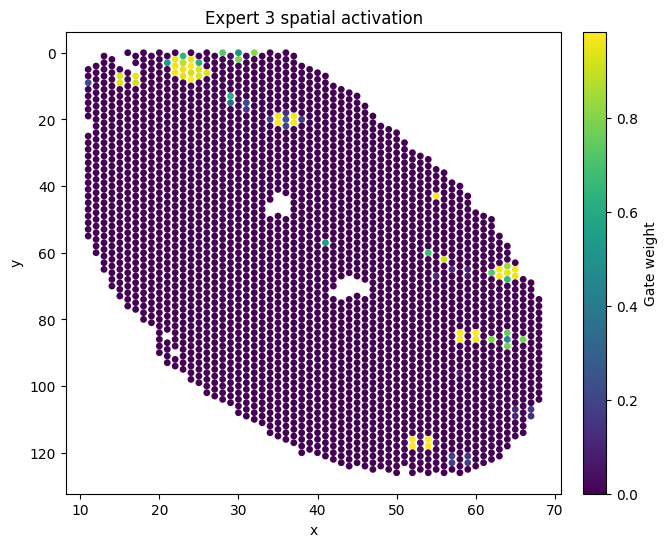

In [23]:
from utils.moe_analysis import (
    analyze_moe_routing,
    plot_center_spot_activation_bar,
    plot_expert_spatial_heatmap,
    plot_slice_activation_heatmap,
    save_moe_analysis_tables,
)

moe_results = analyze_moe_routing(
    model=model,
    dataloader=testloader,
    device=device,
    include_images=False,
    include_cell_information=False,
    include_predictions=False,
    include_targets=True,
)

activation_frame = moe_results["activation_frame"]

print("Overall MoE metrics:")
print(moe_results["overall"])
display(moe_results["expert_summary"])
if not moe_results["slice_summary"].empty:
    display(moe_results["slice_summary"])
if not moe_results["region_summary"].empty:
    display(moe_results["region_summary"])

display(activation_frame.head())
plot_center_spot_activation_bar(activation_frame, row_index=0);

if activation_frame["x"].notna().any() and activation_frame["y"].notna().any():
    first_slice = activation_frame["slice_id"].dropna().iloc[0]
    plot_slice_activation_heatmap(activation_frame, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=0, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=1, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=2, slice_id=first_slice);
    plot_expert_spatial_heatmap(activation_frame, expert_index=3, slice_id=first_slice);
else:
    print(
        "Spatial coordinates were not recovered from the sample ids. "
        "Pass `sample_metadata_resolver` to `analyze_moe_routing(...)` if you want spatial heatmaps."
    )

# Optional: save the analysis tables to disk.
# save_moe_analysis_tables(moe_results, output_dir="./moe_analysis")



### Optional MoE Training Trajectory Summary

If epoch-level tracking was enabled during training, the next cell summarizes how expert usage changed over time.


,epoch,num_center_spots,num_experts,usage_entropy_normalised,top1_entropy_normalised,effective_expert_count,dominant_expert_fraction,mean_weight_l1_to_uniform,balance_loss,top1_l1_to_uniform,mean_spot_entropy,std_spot_entropy,mean_gate_margin,std_gate_margin,router_temperature,router_entropy_penalty,expert_output_cosine_mean,expert_output_cosine_std
0,1,2655,4,0.989007,0.523854,3.939503,0.320706,0.141413,0.013414,0.988701,0.827967,0.146091,0.112434,0.097789,1.0,0.828049,0.825079,0.106475
1,2,2655,4,0.862112,0.511885,3.304025,0.440489,0.590889,0.099772,0.993220,0.505479,0.037400,0.591955,0.047910,1.0,0.505636,0.296070,0.639968
2,3,2655,4,0.679246,0.488783,2.564170,0.586067,0.749070,0.202645,1.000000,0.261438,0.295138,0.749094,0.294309,1.0,0.261525,0.295161,0.569747
3,4,2655,4,0.531463,0.470533,2.089164,0.641286,0.963742,0.291823,0.998493,0.087912,0.064260,0.963700,0.048510,1.0,0.087606,0.362633,0.449059
4,5,2655,4,0.490019,0.481106,1.972518,0.613889,0.996468,0.287547,1.000000,0.005921,0.060648,0.996439,0.048068,0.7,0.005922,0.299123,0.419740
5,6,2655,4,0.489165,0.482254,1.970183,0.622028,0.995592,0.291454,0.998493,0.007154,0.061107,0.995987,0.045686,0.7,0.006668,0.225929,0.424399
6,7,2655,4,0.498731,0.489309,1.996485,0.614750,0.991662,0.286065,0.996234,0.011086,0.066149,0.992709,0.062714,0.7,0.011196,0.085637,0.382753
7,8,2655,4,0.511540,0.511330,2.032252,0.579090,0.989872,0.272433,0.989454,0.003938,0.040863,0.997520,0.034257,0.7,0.004043,0.011719,0.445637
8,9,2655,4,0.558970,0.555694,2.170369,0.621973,0.936168,0.271257,0.937476,0.016177,0.086946,0.987069,0.085347,0.7,0.016808,-0.035826,0.507855
9,10,2655,4,0.549181,0.547665,2.141116,0.607777,0.952008,0.270388,0.952542,0.006308,0.058196,0.994955,0.056854,0.5,0.006023,-0.089692,0.530382


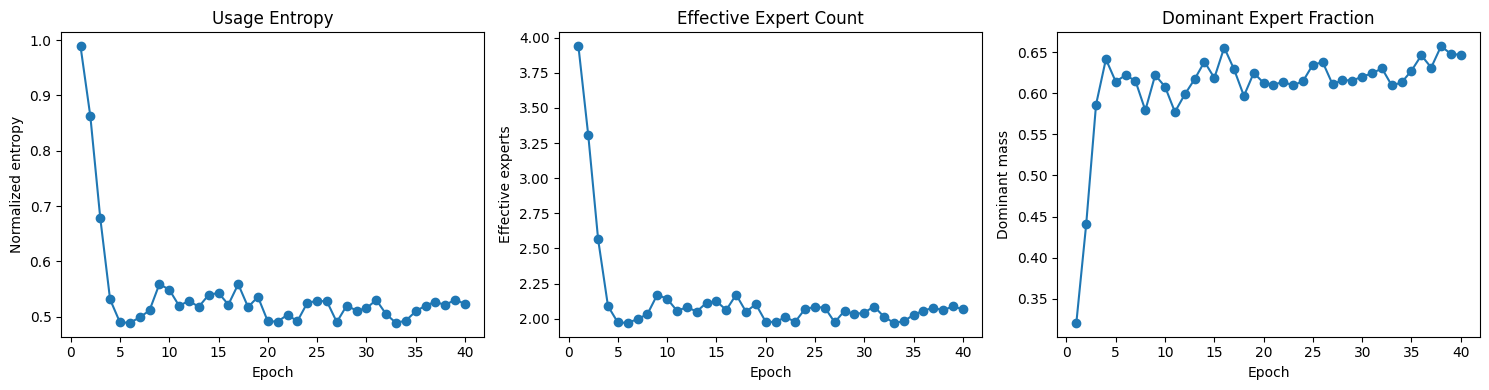

In [24]:
import matplotlib.pyplot as plt

if not moe_epoch_frames:
    print(
        "No epoch-level MoE trajectory was recorded. "
        "Set `track_moe_during_training = True` before training and rerun the notebook if you want this summary."
    )
else:
    moe_epoch_trajectory = summarize_epoch_trajectory(moe_epoch_frames)
    display(moe_epoch_trajectory)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["usage_entropy_normalised"], marker="o")
    axes[0].set_title("Usage Entropy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Normalized entropy")

    axes[1].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["effective_expert_count"], marker="o")
    axes[1].set_title("Effective Expert Count")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Effective experts")

    axes[2].plot(moe_epoch_trajectory["epoch"], moe_epoch_trajectory["dominant_expert_fraction"], marker="o")
    axes[2].set_title("Dominant Expert Fraction")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dominant mass")

    plt.tight_layout()

# Optional: save the trajectory table to disk.
# moe_epoch_trajectory.to_csv("./moe_analysis/moe_epoch_trajectory.csv", index=False)

